In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_excel("/content/Online Retail.xlsx", sheet_name = "Online Retail", header = 0, skiprows = 0)

####sheet_name to select particular sheet in excel file,here only one is present
####header is used to denote the row i will use as header, the value is the index value of row starting from 0(first row)
####skiprows is used to skip rows in analysis, here its 0 cause i dont wanna skip any

In [94]:
df_clean = df.copy() #deep copy

####Checking Structure and Intricacies

In [95]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [96]:
df_clean.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [97]:
df_clean.shape

(541909, 8)

In [98]:
df_clean.duplicated().sum()

np.int64(5268)

In [99]:
df_clean.drop_duplicates(inplace = True)

In [100]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536641.000000,536641,536641.000000,401604.000000
mean,9.620029,2011-07-04 08:57:06.087421952,4.632656,15281.160818
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,219.130156,NaN,97.233118,1714.006089


In [101]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


###Dropping Features with unique identifiers for each customer and purchase, they dont affect clustering

In [102]:
df_clean.drop(columns=['CustomerID','InvoiceNo'],inplace = True)

###Filling Unknown

In [103]:
df_clean['Description'] = df_clean['Description'].fillna('Unknown')

####Splitting Date

In [104]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

df_clean.drop(columns=['InvoiceDate'], inplace = True)


In [105]:
df_clean.head()

,StockCode,Description,Quantity,UnitPrice,Country,Year,Month,Hour
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom,2010,12,8
1,71053,WHITE METAL LANTERN,6,3.39,United Kingdom,2010,12,8
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom,2010,12,8
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom,2010,12,8
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom,2010,12,8


In [106]:
df_clean['Month'].nunique()

12

###Bar Plots

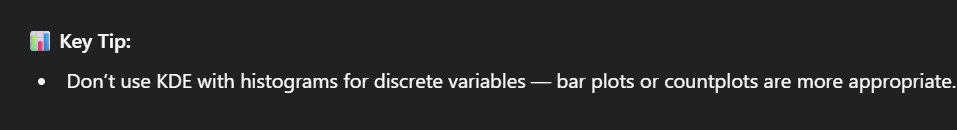

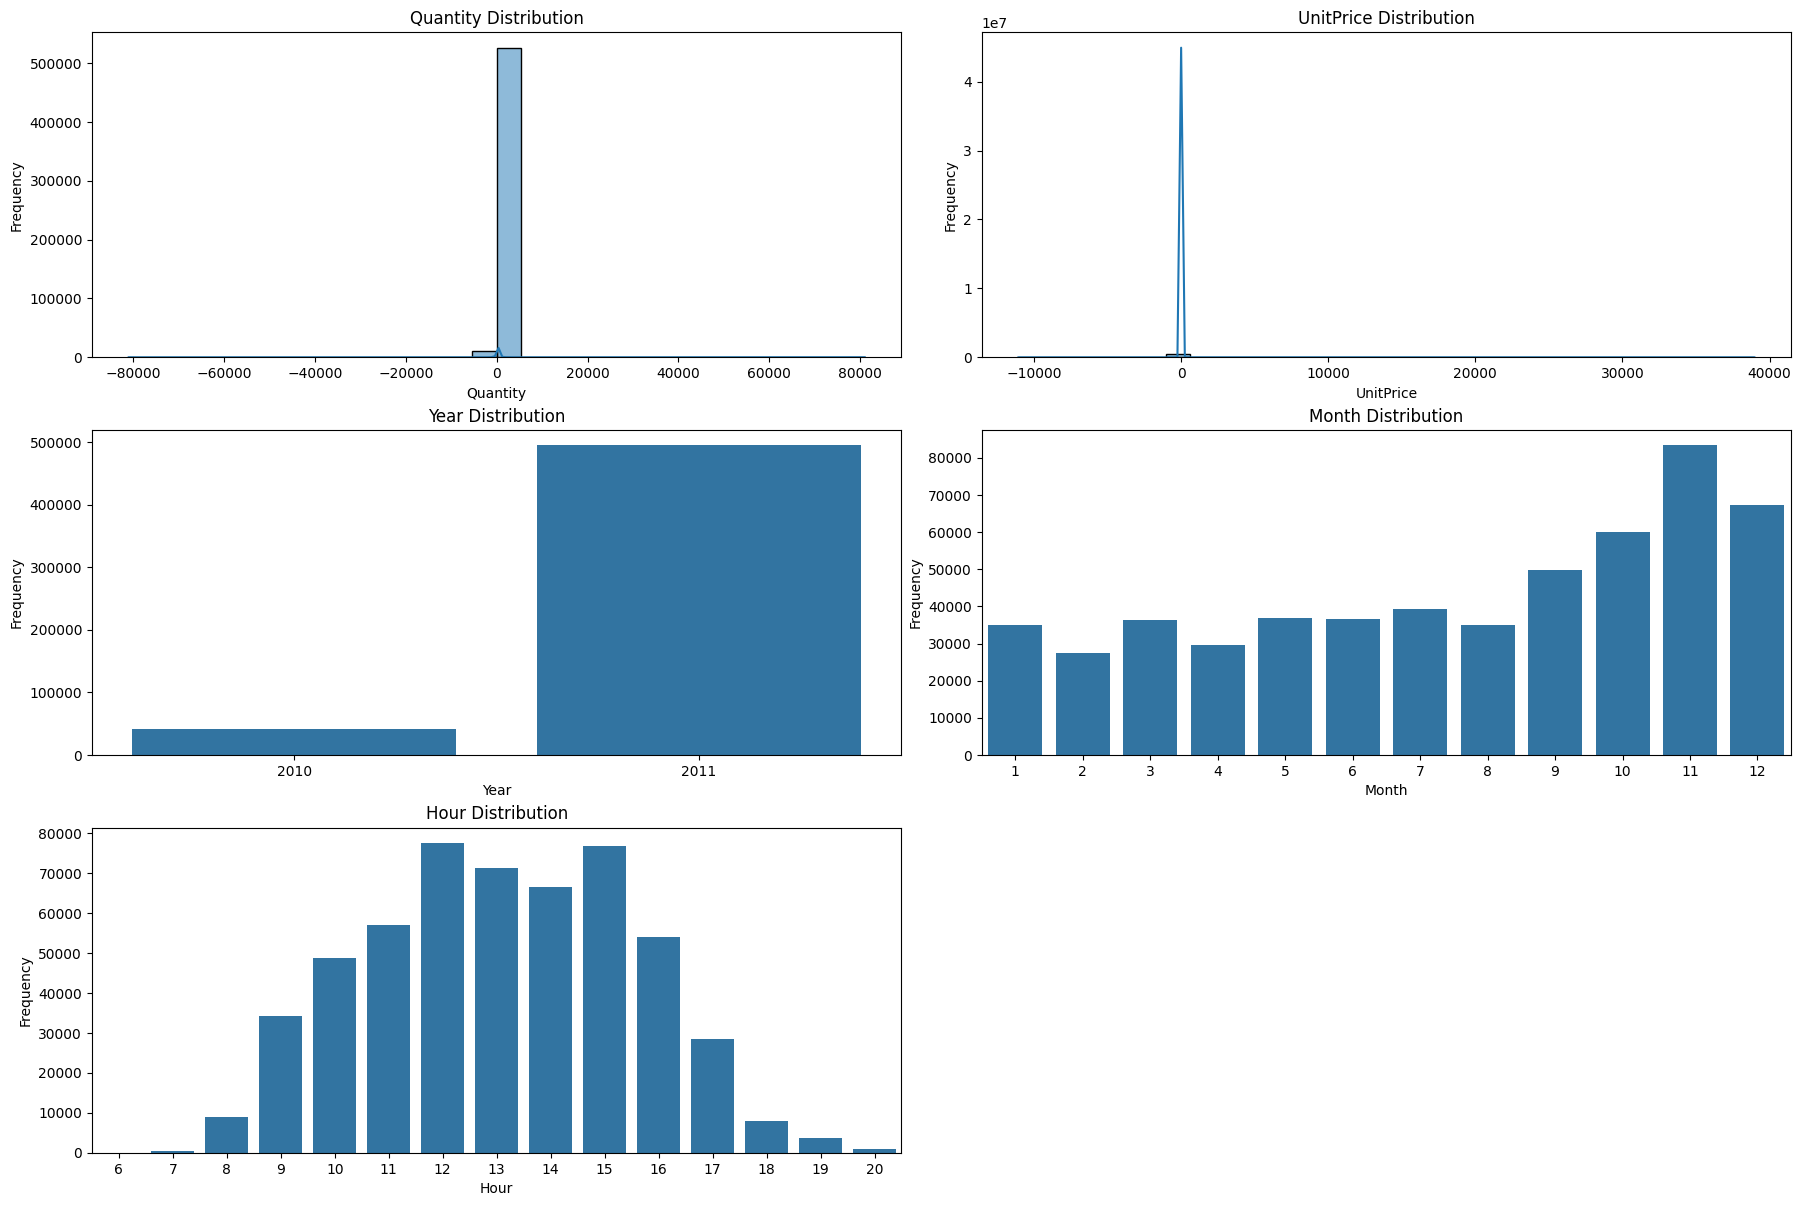

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['Quantity', 'UnitPrice', 'Year', 'Month', 'Hour']

plt.figure(figsize=(18, 12))

for i, col in enumerate(columns):
    ax = plt.subplot(3, 2, i + 1)

    if col in ['Year', 'Month', 'Hour']:
        # Bar plot for discrete variables
        sns.countplot(x=col, data=df_clean, ax=ax)
    else:
        # Histogram + KDE for continuous variables
        sns.histplot(df_clean[col], kde=True, bins=30, ax=ax)

    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout(pad=0.5)
plt.show()


###Boxplots

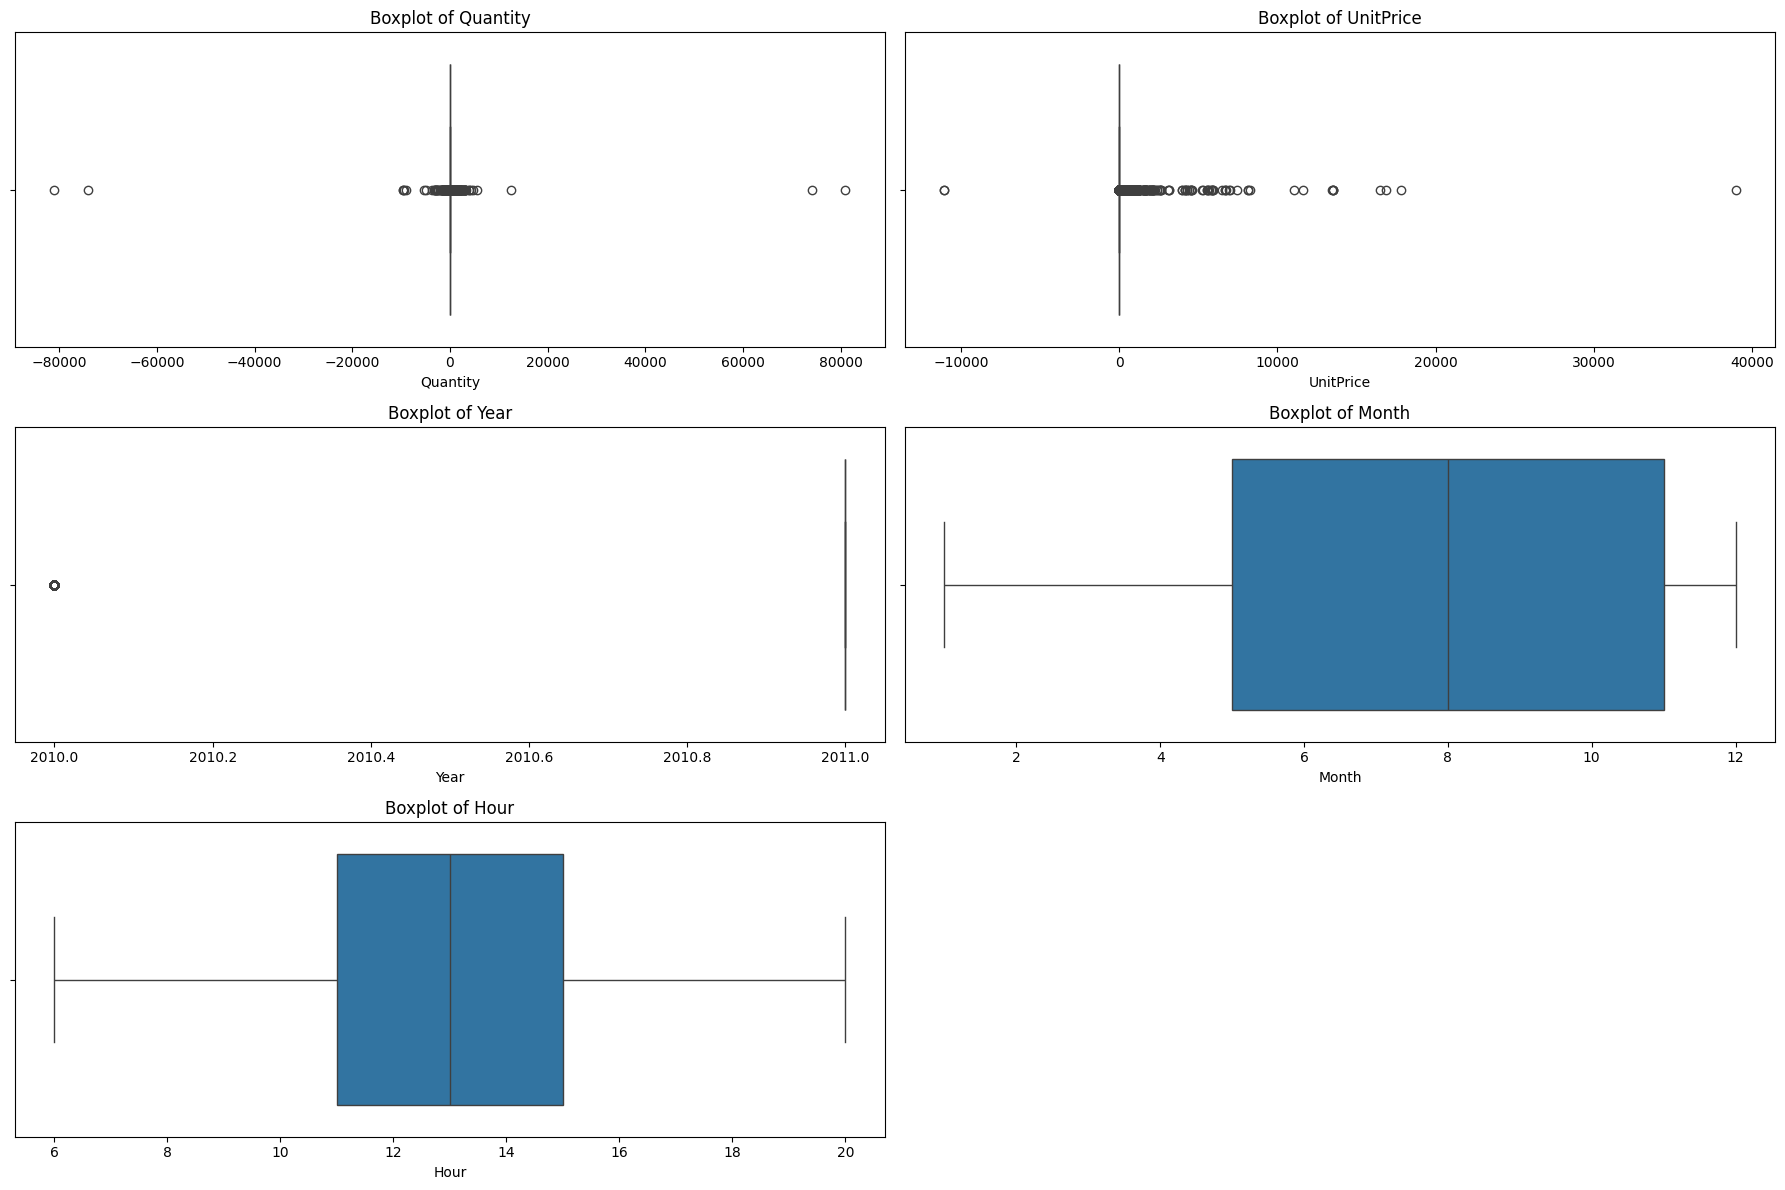

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to visualize
columns = ['Quantity', 'UnitPrice', 'Year', 'Month', 'Hour']

plt.figure(figsize=(18, 12))

for i, col in enumerate(columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


####Outliers in Unit Price and Quantity

In [109]:
df_clean[df_clean['UnitPrice'] < 0]

,StockCode,Description,Quantity,UnitPrice,Country,Year,Month,Hour
299983,B,Adjust bad debt,1,-11062.06,United Kingdom,2011,8,14
299984,B,Adjust bad debt,1,-11062.06,United Kingdom,2011,8,14


In [110]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]  #only keeping positive unit price

In [111]:
df_clean[df_clean['UnitPrice'] > 10000]

,StockCode,Description,Quantity,UnitPrice,Country,Year,Month,Hour
15016,AMAZONFEE,AMAZON FEE,-1,13541.33,United Kingdom,2010,12,15
15017,AMAZONFEE,AMAZON FEE,1,13541.33,United Kingdom,2010,12,15
16232,AMAZONFEE,AMAZON FEE,-1,13474.79,United Kingdom,2010,12,15
16356,AMAZONFEE,AMAZON FEE,-1,13541.33,United Kingdom,2010,12,15
43702,AMAZONFEE,AMAZON FEE,-1,16888.02,United Kingdom,2011,1,9
43703,AMAZONFEE,AMAZON FEE,-1,16453.71,United Kingdom,2011,1,9
222681,M,Manual,-1,38970.00,United Kingdom,2011,6,15
299982,B,Adjust bad debt,1,11062.06,United Kingdom,2011,8,14
524601,AMAZONFEE,AMAZON FEE,-1,11586.50,United Kingdom,2011,12,11
524602,AMAZONFEE,AMAZON FEE,-1,17836.46,United Kingdom,2011,12,11


In [112]:
df_clean[df_clean['Quantity'] < 0]

,StockCode,Description,Quantity,UnitPrice,Country,Year,Month,Hour
141,D,Discount,-1,27.50,United Kingdom,2010,12,9
154,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,United Kingdom,2010,12,9
235,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,United Kingdom,2010,12,10
236,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,United Kingdom,2010,12,10
237,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,United Kingdom,2010,12,10
...,...,...,...,...,...,...,...,...
540449,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,0.83,United Kingdom,2011,12,9
541541,M,Manual,-1,224.69,United Kingdom,2011,12,10
541715,21258,VICTORIAN SEWING BOX LARGE,-5,10.95,United Kingdom,2011,12,11
541716,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,1.25,United Kingdom,2011,12,11


####Negative quantity means returned

In [113]:
df_clean['Returned'] = (df_clean['Quantity'] < 0).astype(int)
df_clean['Quantities Involved'] = df_clean['Quantity'].abs()

df_clean.drop(columns=['Quantity'], inplace = True)

####Very high quantity [>80000]

In [114]:
df_clean[df_clean['Quantities Involved'] > 10000]

,StockCode,Description,UnitPrice,Country,Year,Month,Hour,Returned,Quantities Involved
61619,23166,MEDIUM CERAMIC TOP STORAGE JAR,1.04,United Kingdom,2011,1,10,0,74215
61624,23166,MEDIUM CERAMIC TOP STORAGE JAR,1.04,United Kingdom,2011,1,10,1,74215
540421,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,United Kingdom,2011,12,9,0,80995
540422,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,United Kingdom,2011,12,9,1,80995


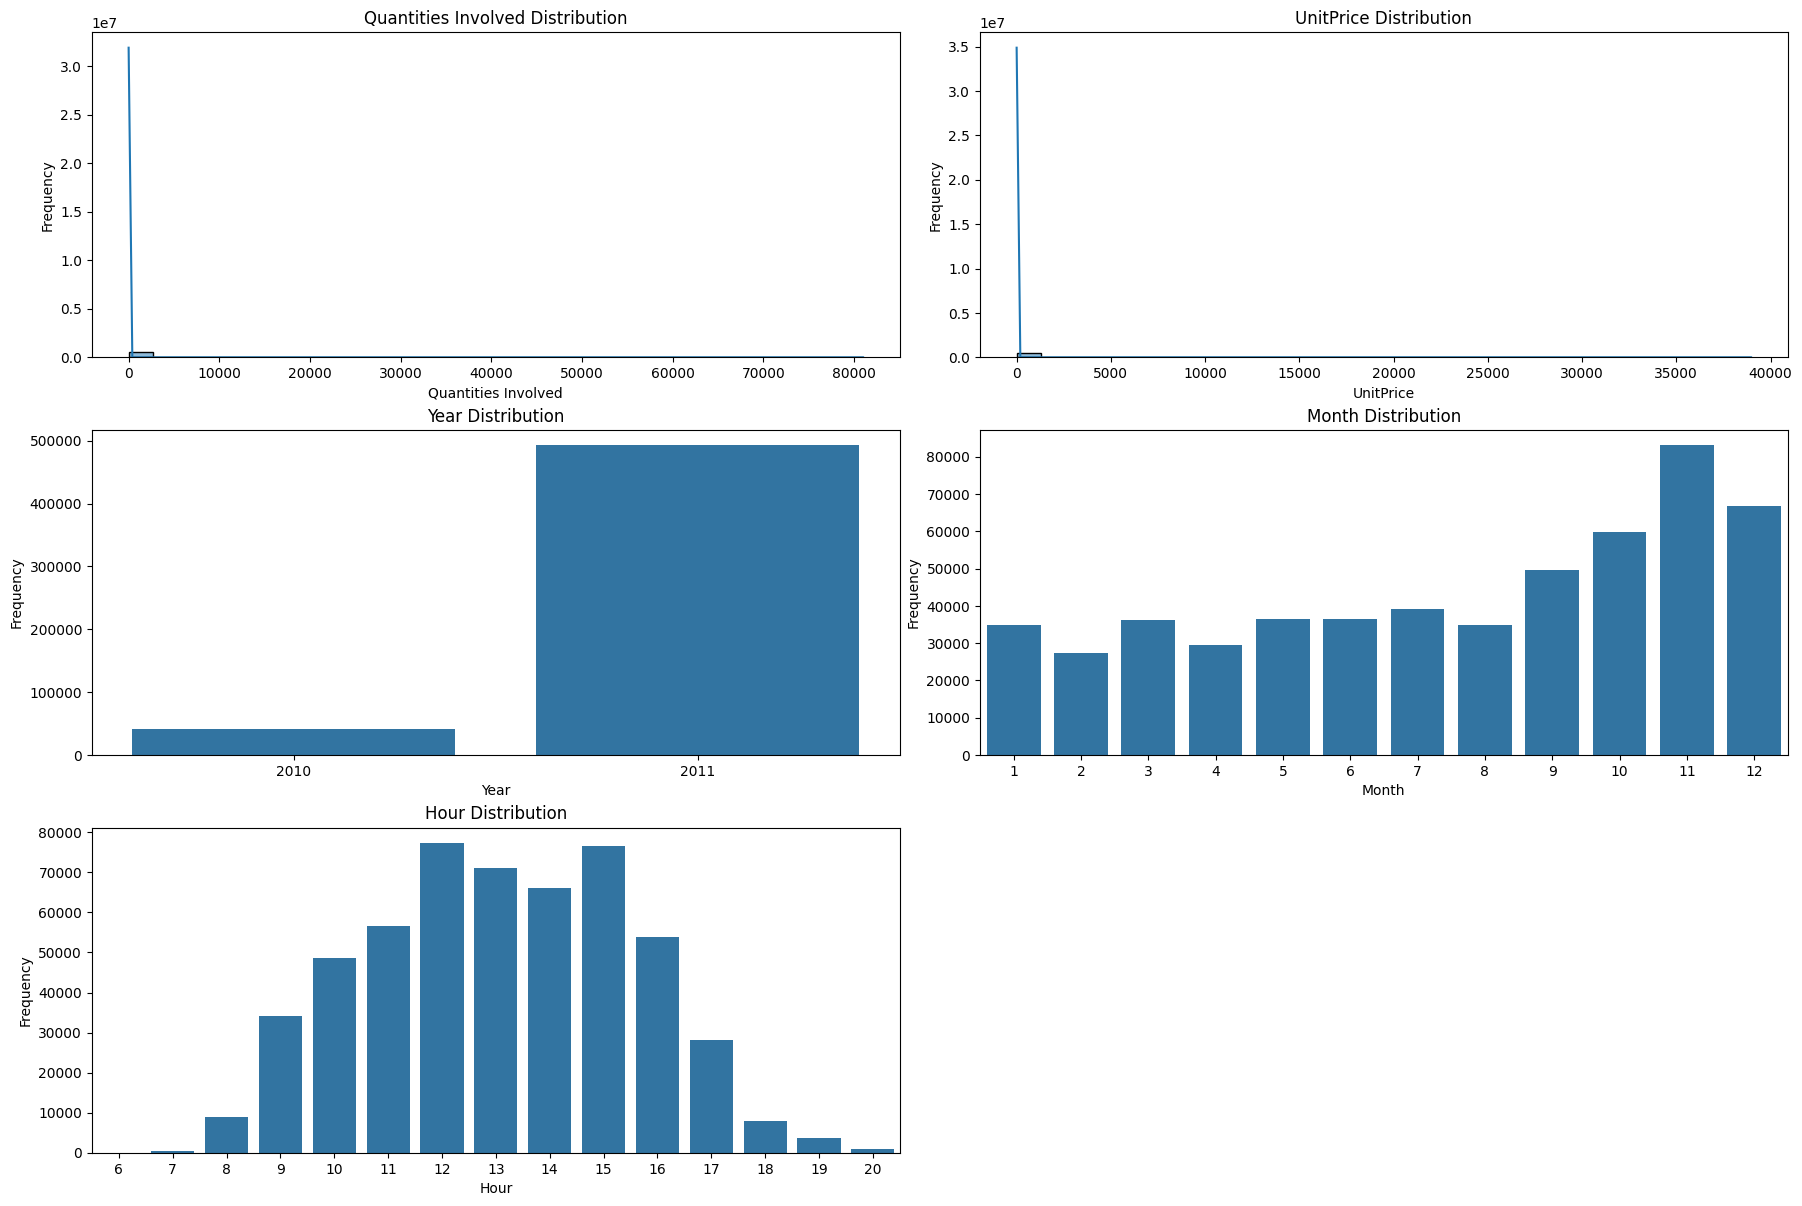

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['Quantities Involved', 'UnitPrice', 'Year', 'Month', 'Hour']

plt.figure(figsize=(18, 12))

for i, col in enumerate(columns):
    ax = plt.subplot(3, 2, i + 1)

    if col in ['Year', 'Month', 'Hour']:
        # Bar plot for discrete variables
        sns.countplot(x=col, data=df_clean, ax=ax)
    else:
        # Histogram + KDE for continuous variables
        sns.histplot(df_clean[col], kde=True, bins=30, ax=ax)

    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout(pad=0.5)
plt.show()


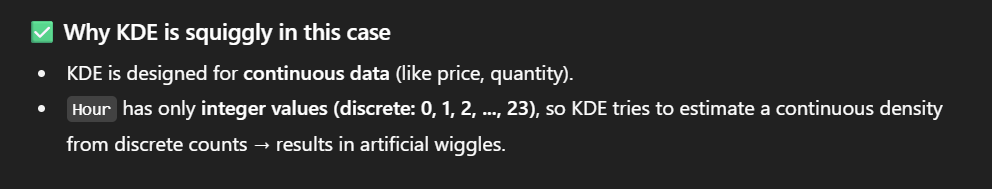

In [116]:
df_clean[df_clean['Quantities Involved'] == df_clean['Quantities Involved'].max()]

,StockCode,Description,UnitPrice,Country,Year,Month,Hour,Returned,Quantities Involved
540421,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,United Kingdom,2011,12,9,0,80995
540422,23843,"PAPER CRAFT , LITTLE BIRDIE",2.08,United Kingdom,2011,12,9,1,80995


In [117]:
df_clean[df_clean['Quantities Involved'] < 10000]

,StockCode,Description,UnitPrice,Country,Year,Month,Hour,Returned,Quantities Involved
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,2010,12,8,0,6
1,71053,WHITE METAL LANTERN,3.39,United Kingdom,2010,12,8,0,6
2,84406B,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,2010,12,8,0,8
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,2010,12,8,0,6
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,2010,12,8,0,6
...,...,...,...,...,...,...,...,...,...
541904,22613,PACK OF 20 SPACEBOY NAPKINS,0.85,France,2011,12,12,0,12
541905,22899,CHILDREN'S APRON DOLLY GIRL,2.10,France,2011,12,12,0,6
541906,23254,CHILDRENS CUTLERY DOLLY GIRL,4.15,France,2011,12,12,0,4
541907,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.15,France,2011,12,12,0,4


####Log Transform Quantities Involved and Unit Price

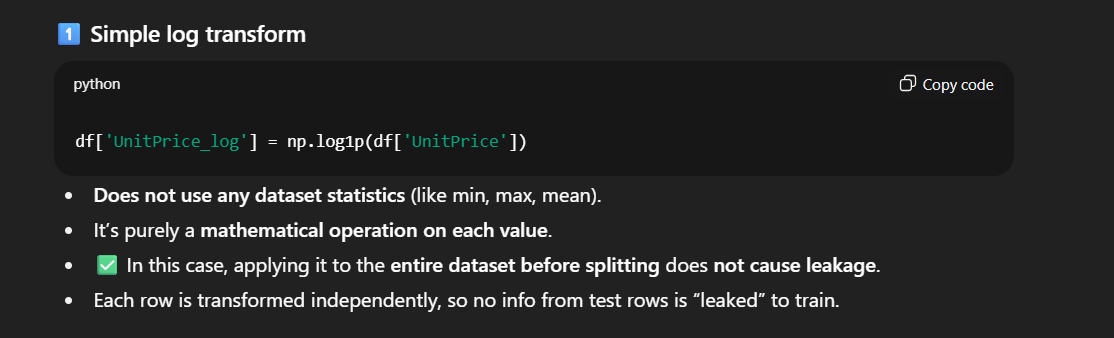

In [118]:
df_clean['UnitPrice'] = np.log1p(df_clean['UnitPrice'])
df_clean['Quantities Involved'] = np.log1p(df_clean['Quantities Involved'])

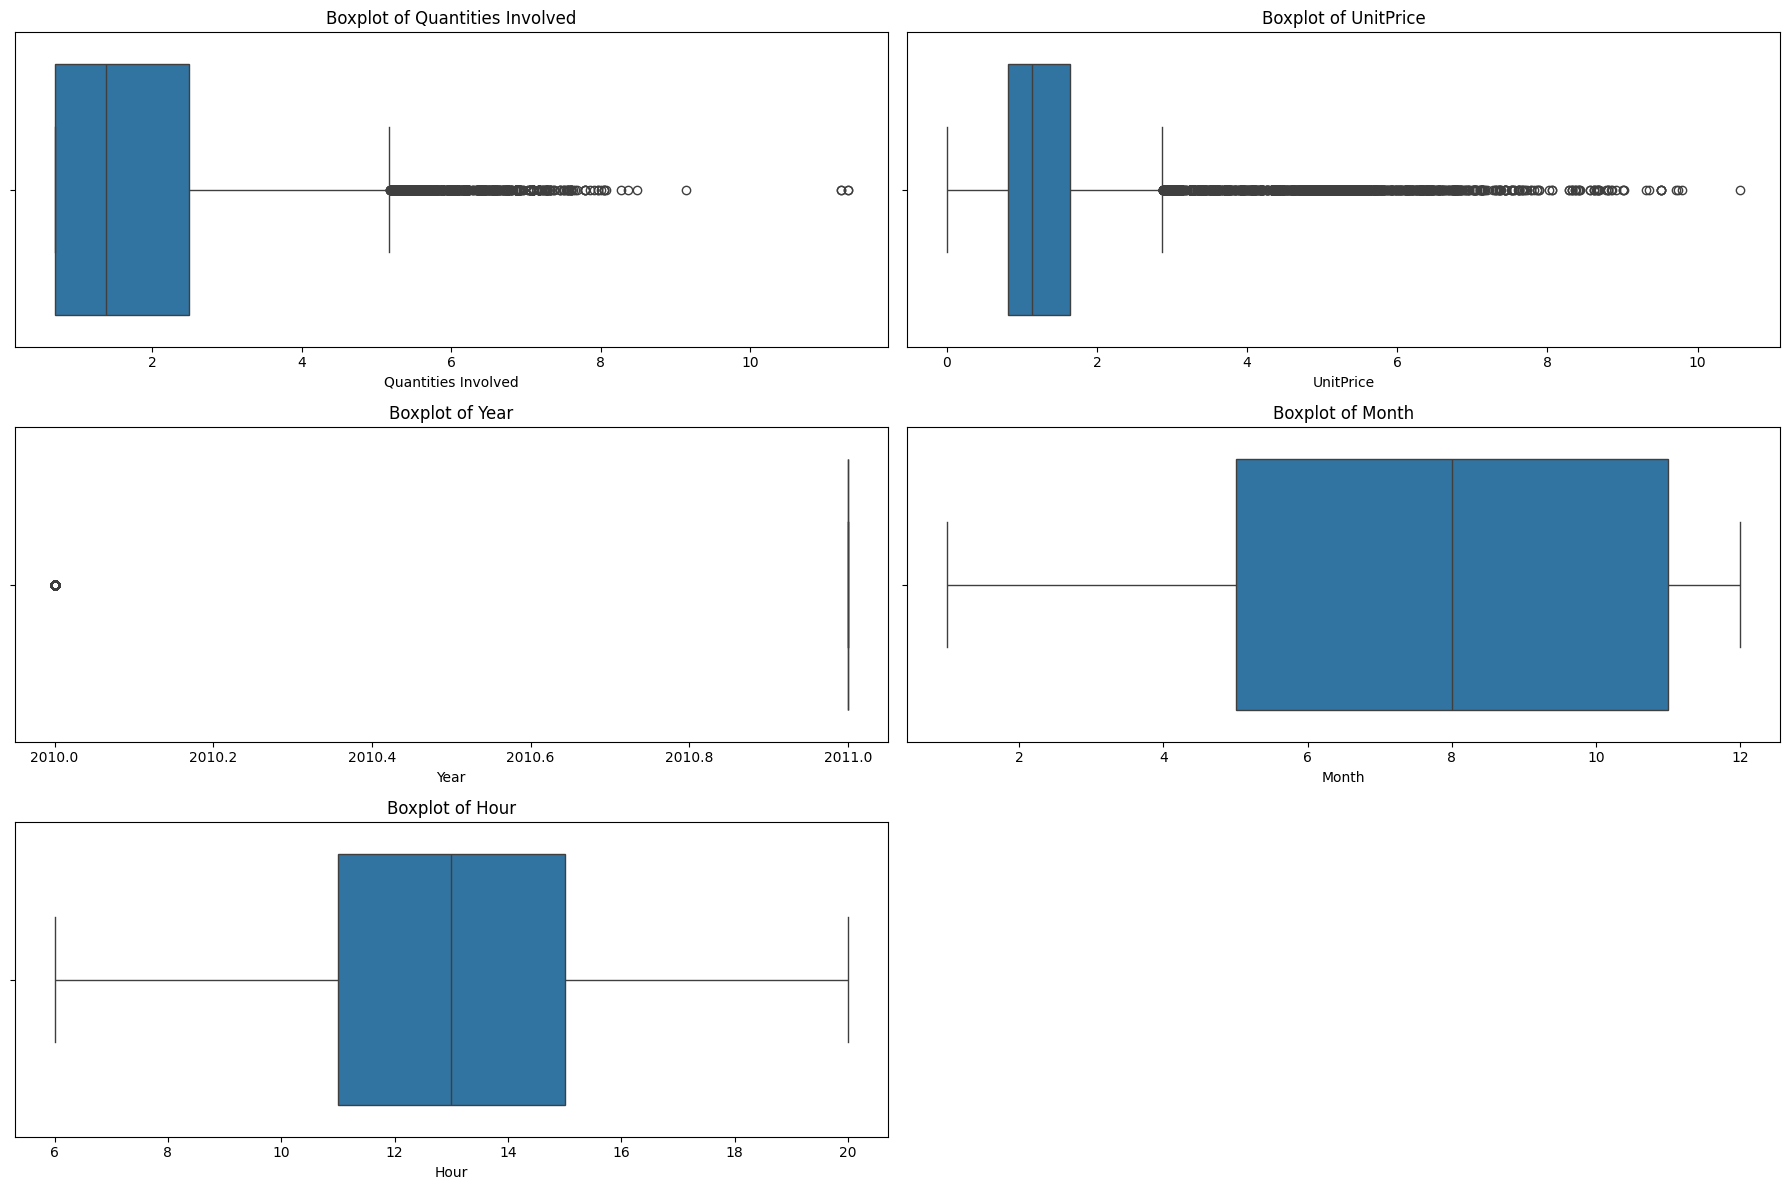

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to visualize
columns = ['Quantities Involved', 'UnitPrice', 'Year', 'Month', 'Hour']

plt.figure(figsize=(18, 12))

for i, col in enumerate(columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


####Skewness Reduced but Outliers still exist, capping/winsorizing to limit values, because i dont wanna drop them, they are real values after all

In [120]:
####UnitPrice
# unit_price_mean = df_clean['UnitPrice'].mean()
# unit_price_std = df_clean['UnitPrice'].std()
# lower_limit_unitprice = unit_price_mean - (3*unit_price_std)
# upper_limit_unitprice = unit_price_mean + (3*unit_price_std)
df_clean['UnitPrice'] = df_clean['UnitPrice'].clip(lower= df_clean['UnitPrice'].quantile(0.01), upper = df_clean['UnitPrice'].quantile(0.99))

####Quantities Involved
# quantity_mean = df_clean['Quantities Involved'].mean()
# quantity_std = df_clean['Quantities Involved'].std()
# lower_limit_quantity = quantity_mean - (3*quantity_std)
# upper_limit_quantity = quantity_mean + (3*quantity_std)
df_clean['Quantities Involved'] = df_clean['Quantities Involved'].clip(lower= df_clean['Quantities Involved'].quantile(0.01), upper = df_clean['Quantities Involved'].quantile(0.99))

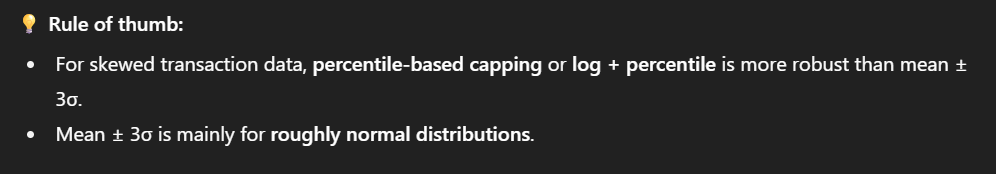

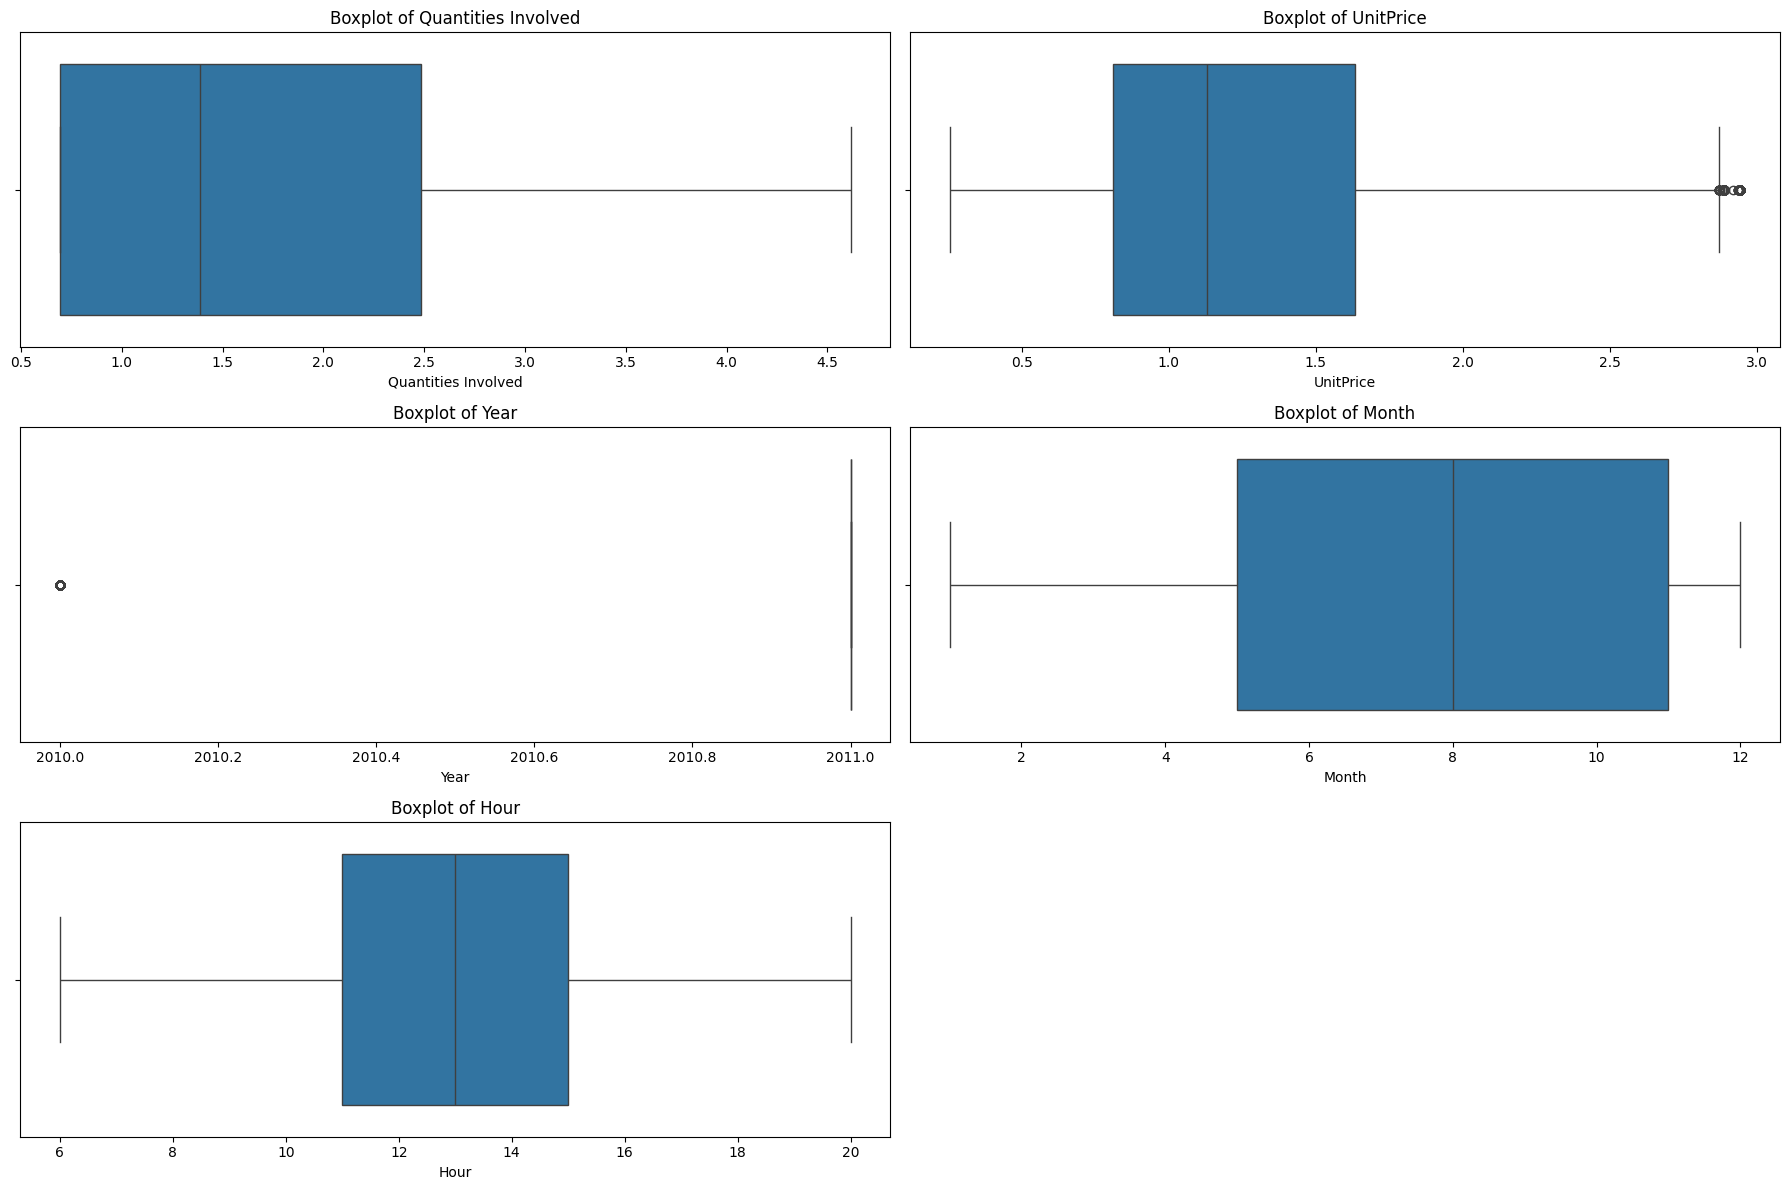

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to visualize
columns = ['Quantities Involved', 'UnitPrice', 'Year', 'Month', 'Hour']

plt.figure(figsize=(18, 12))

for i, col in enumerate(columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


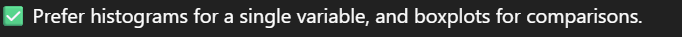

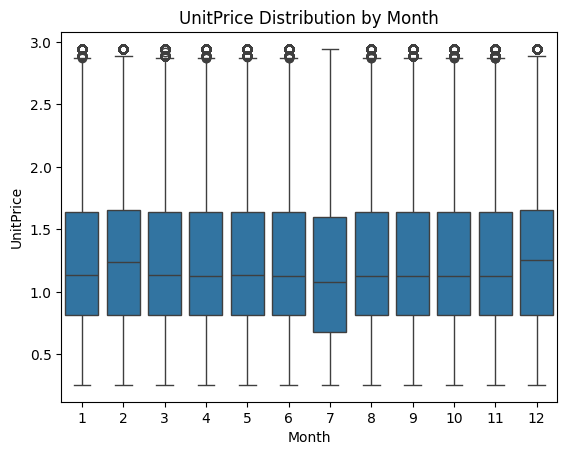

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Distribution of UnitPrice by Month
sns.boxplot(x='Month', y='UnitPrice', data=df_clean)
plt.title('UnitPrice Distribution by Month')
plt.xlabel('Month')
plt.ylabel('UnitPrice')
plt.show()


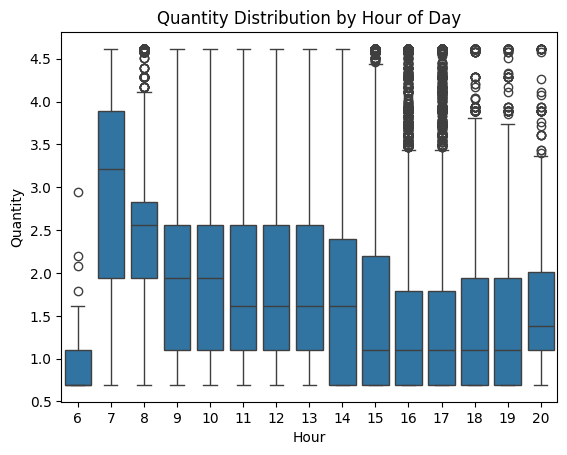

In [123]:
sns.boxplot(x='Hour', y='Quantities Involved', data=df_clean)
plt.title('Quantity Distribution by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Quantity')
plt.show()


####Revised Capping to eliminate remaining outleirs ,set upper limit to quantile(0.95)

In [124]:
df_clean['UnitPrice'] = df_clean['UnitPrice'].clip(lower= df_clean['UnitPrice'].quantile(0.01), upper = df_clean['UnitPrice'].quantile(0.95))
df_clean['Quantities Involved'] = df_clean['Quantities Involved'].clip(lower= df_clean['Quantities Involved'].quantile(0.01), upper = df_clean['Quantities Involved'].quantile(0.95))

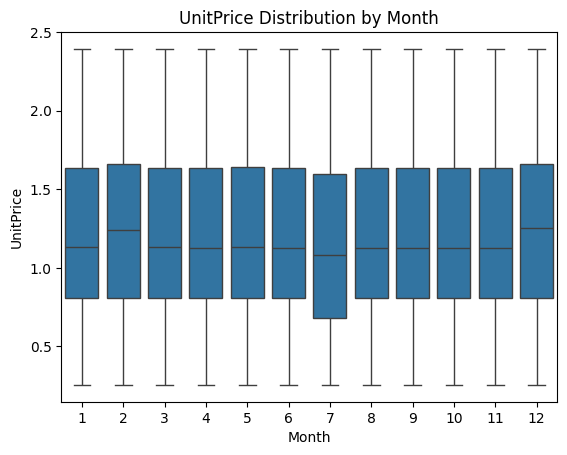

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Distribution of UnitPrice by Month
sns.boxplot(x='Month', y='UnitPrice', data=df_clean)
plt.title('UnitPrice Distribution by Month')
plt.xlabel('Month')
plt.ylabel('UnitPrice')
plt.show()


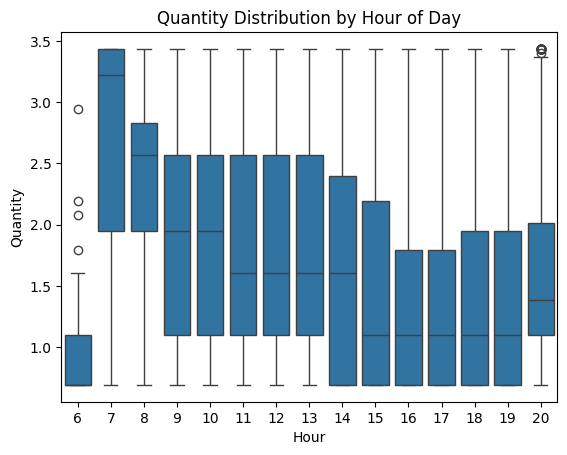

In [126]:
sns.boxplot(x='Hour', y='Quantities Involved', data=df_clean)
plt.title('Quantity Distribution by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Quantity')
plt.show()


####Remaining Outliers

In [133]:
q1 = df_clean['Quantities Involved'].quantile(0.25)
q3 = df_clean['Quantities Involved'].quantile(0.75)
iqr = q3 - q1
outliers = df_clean[(df_clean['Quantities Involved'] > q3 + (1.5*iqr)) | (df_clean['Quantities Involved'] < q1 - (1.5*iqr))]
print("Outlier Count : ",outliers.shape[0])
print(outliers)

Outlier Count :  0
Empty DataFrame
Columns: [StockCode, Description, UnitPrice, Country, Year, Month, Hour, Returned, Quantities Involved]
Index: []


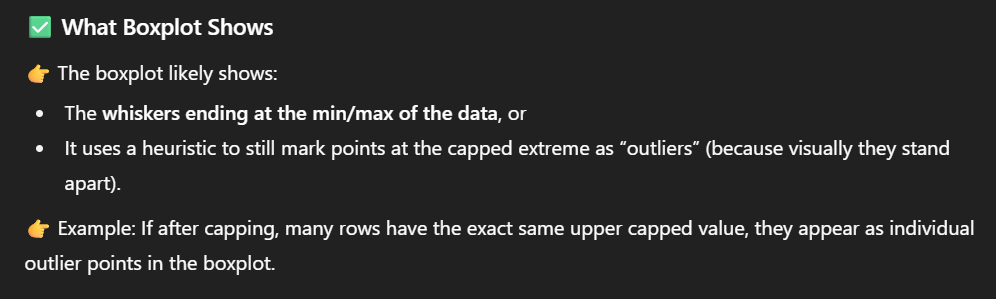

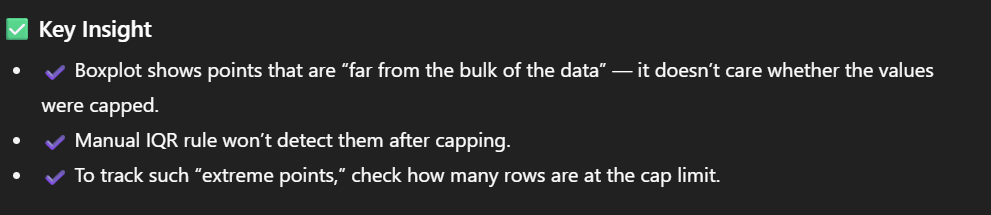

In [134]:
df_clean.head()

,StockCode,Description,UnitPrice,Country,Year,Month,Hour,Returned,Quantities Involved
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1.266948,United Kingdom,2010,12,8,0,1.945910
1,71053,WHITE METAL LANTERN,1.479329,United Kingdom,2010,12,8,0,1.945910
2,84406B,CREAM CUPID HEARTS COAT HANGER,1.321756,United Kingdom,2010,12,8,0,2.197225
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,1.479329,United Kingdom,2010,12,8,0,1.945910
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,1.479329,United Kingdom,2010,12,8,0,1.945910


####Rounding Quantities to 2 decimal places

In [ ]:
df_clean['Quantities Involved'] = df_clean['Quantities Involved'].round(2)
df_clean['UnitPrice'] = df_clean['UnitPrice'].round(3)

###Preprocessing the Text Feature

In [ ]:
#df_clean['Description']
# !pip install nltk  [run once]

#i wont use spacy or xtreme nlp techniques
import re
import nltk
import unicodedata

from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer

# nltk.download("wordnet") [run once]

wnl = WordNetLemmatizer()

df_clean['Description'] = df_clean['Description'].str.lower()
df_clean['Description'] = df_clean['Description'].apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]",'',str(x)))
df_clean['Description'] = df_clean['Description'].apply(lambda x: unicodedata.normalize('NFC',x))
df_clean['Description'] = df_clean['Description'].apply(lambda x: x.split())
df_clean['Description'] = df_clean['Description'].apply(lambda x: [wnl.lemmatize(i) for i in x])   #enclose within list or there will be error because apply function only returns one thing, without list ,it becomes multi

cv = CountVectorizer(max_features = 1500, stop_words = 'english')

# df_clean['Description'] = cv.fit_transform(df_clean['Description'])
df_clean['Description']



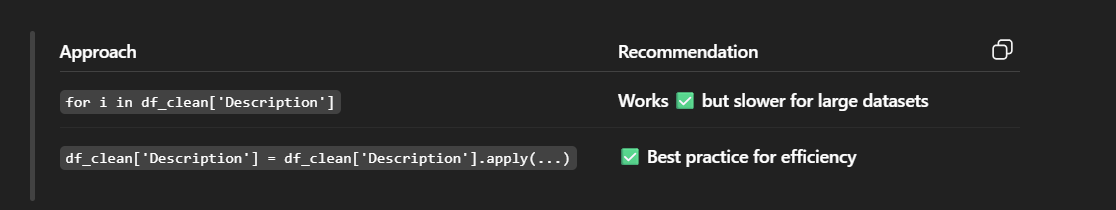